# Cyberbullying Tweets Multiclassification
Dataset contains tweets with several labels. My aim is to experiment and build experience with multiclassification (and further my natural language processing skills) on this dataset.

A specific aim I have initially: train logistic regressions for every class except one ('not_cyberbullying' makes sense as the base class). Then, I will manually combine these K-1 models (where K is number of classes) into final scores for each class.

In [300]:
import pandas as pd
import numpy as np

from nltk import wordpunct_tokenize
from nltk.stem import WordNetLemmatizer

from math import log

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns


# 0 Set Up

## 0.1 Load Dataset

In [185]:
df = pd.read_csv(r'cyberbullying_tweets.csv')
df

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying
...,...,...
47687,"Black ppl aren't expected to do anything, depe...",ethnicity
47688,Turner did not withhold his disappointment. Tu...,ethnicity
47689,I swear to God. This dumb nigger bitch. I have...,ethnicity
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,ethnicity


In [186]:
df['tweet_text'].iloc[4]

'@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account.  Like Islam, it is all lies.'

In [187]:
# Split data into 70% train, 20% validation, 10% test
train_df, initial_test_df = train_test_split(df,test_size=0.3,train_size=0.7,random_state=42,stratify=df['cyberbullying_type'])
valid_df, test_df  = train_test_split(initial_test_df,test_size=1/3,train_size=2/3,random_state=42,stratify=initial_test_df['cyberbullying_type'])


print('Train (70%):')
print(train_df['cyberbullying_type'].value_counts())
print()
print('Validation (20%):')
print(valid_df['cyberbullying_type'].value_counts())
print()
print('Test (10%):')
print(test_df['cyberbullying_type'].value_counts())

Train (70%):
cyberbullying_type
religion               5599
age                    5594
gender                 5581
ethnicity              5573
not_cyberbullying      5561
other_cyberbullying    5476
Name: count, dtype: int64

Validation (20%):
cyberbullying_type
religion               1599
age                    1598
gender                 1595
ethnicity              1592
not_cyberbullying      1589
other_cyberbullying    1565
Name: count, dtype: int64

Test (10%):
cyberbullying_type
religion               800
age                    800
gender                 797
ethnicity              796
not_cyberbullying      795
other_cyberbullying    782
Name: count, dtype: int64


In [188]:
train_df

,tweet_text,cyberbullying_type
41493,FUCK THEM DUMB NIGGERS,ethnicity
47029,“@Pretty_BSJ: Bitch stfu .RT @tayyoung_: FUCK ...,ethnicity
45609,I refuse to step foot in Hip Hop Chicken. Them...,ethnicity
2626,"Dou um empurrão em uma pessoa, isso se chama :...",not_cyberbullying
16259,This is just gross. Signed a #Christian woman ...,religion
...,...,...
14458,👧👧👧👧 …,gender
47509,@_basichoesADORE: fuck you fat white bitch. RT...,ethnicity
38645,Fuck you and your mom..,age
1806,"Read my response to ""Quem mais sofre bullying:...",not_cyberbullying


In [189]:
#reset indices on dfs
train_df = train_df.reset_index(drop=True)

valid_df = valid_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)


## 0.2 Tweet Cleaning

In [190]:
# initial thoughts for handling the data:
# some tweets have @ in them, some do not, we should capture this.
# hashtags are important too don't cut them all out
# in general, think about punctuation we remove


In [191]:
# list of stopwords (common words not useful for predictions) 
stopwords = []

# list of words to keep i.e. remove from stopwords
remove_from_stopwords = ['not','10','39']

# Open the file
with open("stopwords-en.txt", "r") as f:
    # Loop through each line
    for line in f:
        # Strip newline characters if needed
        line = line.strip()
        if line not in remove_from_stopwords:
            stopwords += [line]

#finally, make it a set for speed of lookup
stopwords = set(stopwords)
# inspect the set
print(stopwords)


{'null', 'noted', 'full', 'se', 'gone', 'right', 'thereby', 'kg', 'whither', 'course', 'ga', 'ao', 'looks', 'saying', "one's", 'no-one', 'uz', 'e', 'didnt', 'fx', 'furthered', "should've", 'ly', "let's", 'vi', 'cr', 'doing', 'hasnt', 'against', 'mq', "needn't", 'will', 'thru', 'ninety', 'one', 'pf', 'particularly', 'research', 'net', 'sometime', 'qv', 'no', 'pr', 'computer', 'worked', 'somewhere', 'rooms', 'mainly', 'je', 'somehow', 'yourselves', 'hers', 'cf', 'w', 'www', 'puts', "'tis", "there've", 'ahead', 'y', "wouldn't", 'obviously', 'ch', 'zm', 'caption', 'got', 'ourselves', "you'd", 'thanx', 'faces', 'oughtnt', 'usefully', 'usually', 'longest', 'un', 'eleven', 'dj', 'everybody', 'is', 'beginnings', 'likely', 'hereafter', 'copy', 'successfully', 'furthering', 'throug', 'wed', 'i', "'ve", 'am', 'fact', 'doesn', 'took', 'test', 'good', 'con', 'facts', 'enough', 'our', "that's", 'differ', "aren't", 'your', 'less', 'done', 'affected', 'hence', 'contains', 'k', 'information', "he's", '

In [192]:
# finds the root of words, to reduce the feature space
lemmatizer = WordNetLemmatizer()

In [193]:
# now start a function to clean and prepare the raw tweets. We can apply this function to any tweet

def clean_raw_tweet_v1(tweet:str, return_untokenized=False):
    #tokenise
    tokens = wordpunct_tokenize(tweet.lower())
    #lemmatisation i.e. finding the root word of each word, and remove stopwords
    cleaned_tweet_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stopwords]

    #now also return an un-tokenized version so we can use it with sklearn tf-idf. Handle @ and # with care.
    if return_untokenized:
        return (' ').join(cleaned_tweet_tokens)

    else:
        return cleaned_tweet_tokens


In [194]:
#test 0
i=0
print(train_df.iloc[i,:])
print(train_df['tweet_text'][i])
clean_raw_tweet_v1(train_df['tweet_text'][i])
clean_raw_tweet_v1(train_df['tweet_text'][i],True)


tweet_text            FUCK THEM DUMB NIGGERS
cyberbullying_type                 ethnicity
Name: 0, dtype: object
FUCK THEM DUMB NIGGERS


'fuck dumb nigger'

In [195]:
#test 1
i=2
print(train_df.iloc[i,:])
print(train_df['tweet_text'][i])
clean_raw_tweet_v1(train_df['tweet_text'][i])
clean_raw_tweet_v1(train_df['tweet_text'][i],True)

#looks alright but I notice ass becomes as, so could try without lemmatizer if this is a bigger problem

tweet_text            I refuse to step foot in Hip Hop Chicken. Them...
cyberbullying_type                                            ethnicity
Name: 2, dtype: object
I refuse to step foot in Hip Hop Chicken. Them fuck ass egyptians profiting off you dumb niggers. I will not drink the koolaid.


'refuse step foot hip hop chicken . fuck as egyptian profiting dumb nigger . not drink koolaid .'

In [196]:
# now apply tweet cleaning to train,valid and test data
for df in [train_df,valid_df,test_df]:
    df['tokens_v1'] = df['tweet_text'].apply(lambda x: clean_raw_tweet_v1(x))
    df['tweet_v1'] = df['tweet_text'].apply(lambda x: clean_raw_tweet_v1(x,return_untokenized=True))

train_df.head()


,tweet_text,cyberbullying_type,tokens_v1,tweet_v1
0,FUCK THEM DUMB NIGGERS,ethnicity,"[fuck, dumb, nigger]",fuck dumb nigger
1,“@Pretty_BSJ: Bitch stfu .RT @tayyoung_: FUCK ...,ethnicity,"[“@, pretty_bsj, :, bitch, stfu, ., rt, @, tay...",“@ pretty_bsj : bitch stfu . rt @ tayyoung_ : ...
2,I refuse to step foot in Hip Hop Chicken. Them...,ethnicity,"[refuse, step, foot, hip, hop, chicken, ., fuc...",refuse step foot hip hop chicken . fuck as egy...
3,"Dou um empurrão em uma pessoa, isso se chama :...",not_cyberbullying,"[dou, empurrão, em, uma, pessoa, ,, isso, cham...","dou empurrão em uma pessoa , isso chama : - › ..."
4,This is just gross. Signed a #Christian woman ...,religion,"[gross, ., signed, #, christian, woman, jesus,...",gross . signed # christian woman jesus teach l...


In [197]:
valid_df.head()


,tweet_text,cyberbullying_type,tokens_v1,tweet_v1
0,personally. fuck cuba. idk why that dumb nigge...,ethnicity,"[personally, ., fuck, cuba, ., idk, dumb, nigg...",personally . fuck cuba . idk dumb nigger frien...
1,"okay, first of all ure one of the best accs he...",ethnicity,"[,, ure, acc, ., happy, ur, moot, ., continue,...",", ure acc . happy ur moot . continue spread po..."
2,"@jeremy_mesa ""what the fuck was that?!""",other_cyberbullying,"[@, jeremy_mesa, "", fuck, ?!""]","@ jeremy_mesa "" fuck ?!"""
3,"@jennyzhy yea, I get bullied like always by th...",other_cyberbullying,"[@, jennyzhy, yea, ,, bullied, kid, .]","@ jennyzhy yea , bullied kid ."
4,To paraphrase @DanielBShapiro on the death of ...,religion,"[paraphrase, @, danielbshapiro, death, abu, ba...",paraphrase @ danielbshapiro death abu bakr - b...


## 0.3 Binary Targets

In [198]:
# each cyberbullying type (other than 'not_cyberbullying') gets its own binary target
train_targets_dict = {bully_type:np.where(train_df['cyberbullying_type']==bully_type,1,0) 
                      for bully_type in set(train_df['cyberbullying_type'])}

train_targets_dict

{'religion': array([0, 0, 0, ..., 0, 0, 0], shape=(33384,)),
 'gender': array([0, 0, 0, ..., 0, 0, 0], shape=(33384,)),
 'age': array([0, 0, 0, ..., 1, 0, 1], shape=(33384,)),
 'not_cyberbullying': array([0, 0, 0, ..., 0, 1, 0], shape=(33384,)),
 'ethnicity': array([1, 1, 1, ..., 0, 0, 0], shape=(33384,)),
 'other_cyberbullying': array([0, 0, 0, ..., 0, 0, 0], shape=(33384,))}

In [199]:
# each cyberbullying type (other than 'not_cyberbullying') gets its own binary target
valid_targets_dict = {bully_type:np.where(valid_df['cyberbullying_type']==bully_type,1,0) 
                      for bully_type in set(valid_df['cyberbullying_type'])}


In [200]:
# each cyberbullying type (other than 'not_cyberbullying') gets its own binary target
test_targets_dict = {bully_type:np.where(test_df['cyberbullying_type']==bully_type,1,0) 
                      for bully_type in set(test_df['cyberbullying_type'])}


# 1 TF-IDF

## 1.1 TF-IDF to raw tweets

In [201]:
#perform TF_IDF (term freq, inverse doc freq) on entire train dataset. Retain idf values for preparing unseen data

In [202]:
# how many distinct tokens in tokens_v1 on train dataset
train_tokensv1_list = train_df['tokens_v1'].tolist()

print('distinct tokens in train=')
print(len({x for subls in train_tokensv1_list for x in subls}))
# there will be even more in uncleaned! but that is what scikit learn tfidf wants

distinct tokens in train=
45854


In [203]:
# try it out of the box, then we can try coding our own if not


train_rawtweet_list = train_df['tweet_text'].tolist()
tfidf = TfidfVectorizer()
train_tfidf = tfidf.fit_transform(train_rawtweet_list)
print(train_tfidf.shape)
#48269 features, so our lemmatization and stopwords only removes around 2-3k


(33384, 48269)


In [204]:
print('\nidf values:')
for idx,(ele1, ele2) in enumerate(zip(tfidf.get_feature_names_out(), tfidf.idf_)):
    if idx<5:  #only print 50
        print(ele1, ':', ele2)



idf values:
00 : 9.017966703493599
000 : 7.752300330162322
0000841420 : 10.722714795732024
000s : 10.722714795732024
0021 : 10.722714795732024


In [205]:
print('\ntf-idf value:')
print(train_tfidf)



tf-idf value:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 684360 stored elements and shape (33384, 48269)>
  Coords	Values
  (0, 17040)	0.4195160477629058
  (0, 42538)	0.5227892575278005
  (0, 13751)	0.42650830850251975
  (0, 30066)	0.6072794584548713
  (1, 17040)	0.10730830580930019
  (1, 13751)	0.10909686111665023
  (1, 33762)	0.6771785708627222
  (1, 6242)	0.14364555938929907
  (1, 40542)	0.24831240460382872
  (1, 36809)	0.11663234394362239
  (1, 41921)	0.1656088171868767
  (1, 30748)	0.15771590850465975
  (1, 4406)	0.13401896014579825
  (1, 30050)	0.11571469936390964
  (1, 6246)	0.18890852540146796
  (1, 31541)	0.13308600651712224
  (1, 19631)	0.16555861775620953
  (1, 43875)	0.18253715978909466
  (1, 43145)	0.06946338715296081
  (1, 17760)	0.13037941221837807
  (1, 359)	0.3619893179720987
  (1, 39049)	0.26735036397154316
  (2, 17040)	0.1063454026966716
  (2, 42538)	0.13252468985097973
  (2, 13751)	0.1081179088691521
  :	:
  (33382, 8597)	0.2750478689052138
  (33

In [206]:
# apply to validation
valid_rawtweet_list = valid_df['tweet_text'].tolist()
valid_tfidf = tfidf.transform(valid_rawtweet_list)
print(valid_tfidf.shape)


(9538, 48269)


In [207]:
# apply to test
test_rawtweet_list = test_df['tweet_text'].tolist()
test_tfidf = tfidf.transform(test_rawtweet_list)
print(test_tfidf.shape)

(4770, 48269)


### 1.1.1 Try Modelling

In [208]:
train_targets_dict.keys()

dict_keys(['religion', 'gender', 'age', 'not_cyberbullying', 'ethnicity', 'other_cyberbullying'])

In [209]:
# Train
clf = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
clf.fit(train_tfidf, train_targets_dict['religion'])



,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [210]:
def tfidf_logreg_summary(log_reg,X_train,y_train,X_valid,y_valid,tfidf_object=tfidf,print_all=True):

    # identify the non-zero features in model
    indices_of_nonzero_predictors = np.nonzero(log_reg.coef_ != 0)[1]
    features = [el for idx,el in enumerate(tfidf.get_feature_names_out()) if idx in indices_of_nonzero_predictors]
    idx_feature_dict = {idx:el for idx,el in enumerate(tfidf.get_feature_names_out()) if idx in indices_of_nonzero_predictors}

    # Make predictions on training data (for comparison)
    y_train_pred = log_reg.predict(X_train)
    y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]

    # Make predictions on valid data
    y_valid_pred = log_reg.predict(X_valid)
    y_valid_pred_proba = log_reg.predict_proba(X_valid)[:, 1]

    # Calculate performance metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    valid_accuracy = accuracy_score(y_valid, y_valid_pred)

    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    valid_auc = roc_auc_score(y_valid, y_valid_pred_proba)

    # Feature importance (coefficients)
    feature_importance = pd.DataFrame({
        'feature': features,
        'coefficient': log_reg.coef_[0][indices_of_nonzero_predictors],
        'abs_coefficient': np.abs(log_reg.coef_[0][indices_of_nonzero_predictors])
    }).sort_values('abs_coefficient', ascending=False)

    

    # All print statements grouped at the end within if print_all block
    if print_all:
        print("=== Model Performance Results ===")
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Valid Accuracy: {valid_accuracy:.4f}")
        print(f"Training AUC: {train_auc:.4f}")
        print(f"Valid AUC: {valid_auc:.4f}")

        print(f"\nDataset sizes:")
        print(f"Training set: {len(y_train)} samples")
        print(f"Valid set: {len(y_valid)} samples")

        print("\n=== Valid Set Classification Report ===")
        print(classification_report(y_valid, y_valid_pred))

        print("\n=== Valid Set Confusion Matrix ===")
        print(confusion_matrix(y_valid, y_valid_pred))

        print("\n=== Feature Importance (Top 40) ===")
        print(feature_importance.head(40))

        print("\n=== Performance Summary ===")
        print(f"Model trained on {len(y_train)} samples with {len(features)} features")
        print(f"Valid performance: AUC = {valid_auc:.4f}, Accuracy = {valid_accuracy:.4f}")

    
    return feature_importance, idx_feature_dict
    
    

In [211]:
target='religion'
feature_importance, idx_feature_dict = tfidf_logreg_summary(clf, train_tfidf, train_targets_dict[target], valid_tfidf, valid_targets_dict[target])


=== Model Performance Results ===
Training Accuracy: 0.9728
Valid Accuracy: 0.9738
Training AUC: 0.9862
Valid AUC: 0.9882

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7939
           1       0.97      0.87      0.92      1599

    accuracy                           0.97      9538
   macro avg       0.97      0.93      0.95      9538
weighted avg       0.97      0.97      0.97      9538


=== Valid Set Confusion Matrix ===
[[7891   48]
 [ 202 1397]]

=== Feature Importance (Top 40) ===
       feature  coefficient  abs_coefficient
21     muslims    30.078168        30.078168
20      muslim    29.656432        29.656432
3    christian    26.690807        26.690807
14     islamic    16.108397        16.108397
13       islam    15.847272        15.847272
32   terrorism    12.098143        12.098143
30      school   -11.548117

In [212]:
idx_feature_dict

{3553: 'and',
 4104: 'are',
 7531: 'bully',
 9082: 'christian',
 9097: 'christians',
 13751: 'dumb',
 17040: 'fuck',
 17520: 'gay',
 20416: 'humanity',
 20765: 'idiot',
 20771: 'idiots',
 21972: 'is',
 22014: 'isis',
 22022: 'islam',
 22035: 'islamic',
 22891: 'jihad',
 23169: 'jokes',
 27455: 'me',
 28346: 'mkr',
 28488: 'mohammed',
 29164: 'muslim',
 29175: 'muslims',
 30050: 'nigger',
 30910: 'of',
 34755: 'quran',
 34871: 'radical',
 35068: 'rape',
 35727: 'religion',
 36334: 'right',
 36809: 'rt',
 37606: 'school',
 41172: 'support',
 42209: 'terrorism',
 42214: 'terrorist',
 42220: 'terrorists',
 42376: 'the',
 43145: 'to',
 46859: 'woman',
 47689: 'you'}

In [213]:
feature_importance

,feature,coefficient,abs_coefficient
21,muslims,30.078168,30.078168
20,muslim,29.656432,29.656432
3,christian,26.690807,26.690807
14,islamic,16.108397,16.108397
13,islam,15.847272,15.847272
32,terrorism,12.098143,12.098143
30,school,-11.548117,11.548117
25,radical,10.931186,10.931186
8,humanity,10.249329,10.249329
19,mohammed,9.275119,9.275119


## 1.2 TF-IDF on v1clean

In [214]:
# try tf-idf on the tweets we used lemmatization and removed stopwords on


In [215]:
# try it out of the box, then we can try coding our own if not

train_rawtweet_list = train_df['tweet_v1'].tolist()
tfidf = TfidfVectorizer()
train_tfidf = tfidf.fit_transform(train_rawtweet_list)
print(train_tfidf.shape)
#48269 features, so our lemmatization and stopwords only removes around 2-3k


(33384, 44422)


In [216]:
# apply to validation
valid_rawtweet_list = valid_df['tweet_v1'].tolist()
valid_tfidf = tfidf.transform(valid_rawtweet_list)
print(valid_tfidf.shape)


(9538, 44422)


In [217]:
# apply to test
test_rawtweet_list = test_df['tweet_v1'].tolist()
test_tfidf = tfidf.transform(test_rawtweet_list)
print(test_tfidf.shape)

(4770, 44422)


### 1.2.1 Try Modelling

In [218]:
train_targets_dict.keys()

dict_keys(['religion', 'gender', 'age', 'not_cyberbullying', 'ethnicity', 'other_cyberbullying'])

In [219]:
# Train
clf2 = LogisticRegression(penalty='l1', solver='liblinear', C=0.05)
clf2.fit(train_tfidf, train_targets_dict['religion'])



,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.05
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [220]:
target='religion'
feature_importance, idx_feature_dict = tfidf_logreg_summary(clf2, train_tfidf, train_targets_dict[target], valid_tfidf, valid_targets_dict[target])

#equivalent performance (roughly 0.986 AUC) with fewer features! (27 vs 39 in last section!)

=== Model Performance Results ===
Training Accuracy: 0.9655
Valid Accuracy: 0.9688
Training AUC: 0.9816
Valid AUC: 0.9813

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7939
           1       0.97      0.84      0.90      1599

    accuracy                           0.97      9538
   macro avg       0.97      0.92      0.94      9538
weighted avg       0.97      0.97      0.97      9538


=== Valid Set Confusion Matrix ===
[[7892   47]
 [ 251 1348]]

=== Feature Importance (Top 40) ===
      feature  coefficient  abs_coefficient
10     muslim    30.159782        30.159782
1   christian    24.860225        24.860225
16  terrorist    13.944598        13.944598
5       islam    12.495771        12.495771
6     islamic    10.921876        10.921876
15  terrorism     8.773663         8.773663
4       idiot     6.844567        

In [221]:
idx_feature_dict

{7040: 'bully',
 8449: 'christian',
 15730: 'fuck',
 18822: 'humanity',
 19158: 'idiot',
 20323: 'islam',
 20336: 'islamic',
 21426: 'joke',
 26251: 'mkr',
 26385: 'mohammed',
 27008: 'muslim',
 27825: 'nigger',
 32067: 'quran',
 32179: 'radical',
 34704: 'school',
 38846: 'terrorism',
 38850: 'terrorist'}

In [222]:
feature_importance

,feature,coefficient,abs_coefficient
10,muslim,30.159782,30.159782
1,christian,24.860225,24.860225
16,terrorist,13.944598,13.944598
5,islam,12.495771,12.495771
6,islamic,10.921876,10.921876
15,terrorism,8.773663,8.773663
4,idiot,6.844567,6.844567
14,school,-6.068018,6.068018
9,mohammed,3.590049,3.590049
3,humanity,3.484618,3.484618


In [223]:
# so now lets fit models like this for each of the target types!


# 2 Fit Binary Models

## 2.1 Initial LogRegs

In [224]:
#dict to store all the logistic regressions
model_dict = {bully_type:{'model':LogisticRegression(penalty='l1', solver='liblinear', C=0.1),
                          'featimp':None,
                          'featdict':None,
                          }
              for bully_type in set(train_df['cyberbullying_type'])}


In [225]:
# fit all the logistic regressions
for bully_type,bully_dict in model_dict.items():
    if bully_type == 'not_cyberbullying':
        continue
    
    print()
    print("========================")
    print(f'{bully_type}:')
    print("========================")
    print()
    bully_dict['model'].fit(train_tfidf, train_targets_dict[bully_type])
    #print summary and store features info
    bully_dict['featimp'], bully_dict['featdict'] = tfidf_logreg_summary(bully_dict['model'],
                                                                          train_tfidf,
                                                                            train_targets_dict[bully_type],
                                                                              valid_tfidf,
                                                                                valid_targets_dict[bully_type])

    



religion:

=== Model Performance Results ===
Training Accuracy: 0.9742
Valid Accuracy: 0.9745
Training AUC: 0.9862
Valid AUC: 0.9871

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7939
           1       0.96      0.89      0.92      1599

    accuracy                           0.97      9538
   macro avg       0.97      0.94      0.95      9538
weighted avg       0.97      0.97      0.97      9538


=== Valid Set Confusion Matrix ===
[[7878   61]
 [ 182 1417]]

=== Feature Importance (Top 40) ===
      feature  coefficient  abs_coefficient
15     muslim    33.589019        33.589019
3   christian    28.308573        28.308573
9       islam    14.793599        14.793599
10    islamic    14.078201        14.078201
25  terrorist    13.902765        13.902765
24  terrorism    11.752034        11.752034
14   mohammed     9.21

In [226]:
'''
have read through the model fits and they all perform relatively well, here is my summary:

Religion: with 27 features Training AUC: 0.9862 Valid AUC: 0.9871
strong positive predictors stand out i.e. names of religions and religious concepts
label recall is 0.89

gender: 28 features Training AUC: 0.9644 Valid AUC: 0.9691
positive signals like r*pe, mysogynistic slurs, also 'gay' is 7th most predictive
label recall is 0.75

age: 7 features and Training AUC: 0.9910 Valid AUC: 0.9907 is suspiciously good!
school, bullied, bully, girl and kid are only positive signals. n*gger & joke weakly negative
label recall is 0.92

ethnicity: unsurprisingly strong w 24 features Train AUC: 0.9928 Valid AUC: 0.9909
n-word and anti-black slurs are top, 'dumb' 5th most predictive. 'white' is 12th
label recall = 0.85

other_cyberbullying: 36 features with Training AUC: 0.9024 Valid AUC: 0.8985
worse than other models but still strong! ALL negative signals; 'http' is first positive at 18th.
recall of label = 0.1, so the model might as well just classify everything as non-'other_cyberbullying'

'''

"\nhave read through the model fits and they all perform relatively well, here is my summary:\n\nReligion: with 27 features Training AUC: 0.9862 Valid AUC: 0.9871\nstrong positive predictors stand out i.e. names of religions and religious concepts\nlabel recall is 0.89\n\ngender: 28 features Training AUC: 0.9644 Valid AUC: 0.9691\npositive signals like r*pe, mysogynistic slurs, also 'gay' is 7th most predictive\nlabel recall is 0.75\n\nage: 7 features and Training AUC: 0.9910 Valid AUC: 0.9907 is suspiciously good!\nschool, bullied, bully, girl and kid are only positive signals. n*gger & joke weakly negative\nlabel recall is 0.92\n\nethnicity: unsurprisingly strong w 24 features Train AUC: 0.9928 Valid AUC: 0.9909\nn-word and anti-black slurs are top, 'dumb' 5th most predictive. 'white' is 12th\nlabel recall = 0.85\n\nother_cyberbullying: 36 features with Training AUC: 0.9024 Valid AUC: 0.8985\nworse than other models but still strong! ALL negative signals; 'http' is first positive at 

## 2.2 Other vs Not Cyberbullying

### Manual test/tweak

In [227]:
# since 'other_cyberbullying' model is bad, try fitting 'not_cyberbullying' model to take its place
bully_type = 'not_cyberbullying'
bully_dict['model'].fit(train_tfidf, train_targets_dict[bully_type])
#print summary and store features info
bully_dict['featimp'], bully_dict['featdict'] = tfidf_logreg_summary(bully_dict['model'],
                                                                        train_tfidf,
                                                                        train_targets_dict[bully_type],
                                                                            valid_tfidf,
                                                                            valid_targets_dict[bully_type])

# this model isn't much better than the other cyberbullying one

=== Model Performance Results ===
Training Accuracy: 0.8554
Valid Accuracy: 0.8607
Training AUC: 0.8808
Valid AUC: 0.8787

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      7949
           1       0.73      0.26      0.38      1589

    accuracy                           0.86      9538
   macro avg       0.80      0.62      0.65      9538
weighted avg       0.85      0.86      0.83      9538


=== Valid Set Confusion Matrix ===
[[7795  154]
 [1175  414]]

=== Feature Importance (Top 40) ===
      feature  coefficient  abs_coefficient
26     nigger   -11.447456        11.447456
31       rape   -11.177616        11.177616
25     muslim    -8.003298         8.003298
19      idiot    -7.712232         7.712232
8   christian    -7.585722         7.585722
17       girl    -6.840239         6.840239
3       black    -5.743083        

In [228]:
# try different regularisation param
log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=1)
bully_type = 'not_cyberbullying'
log_reg.fit(train_tfidf, train_targets_dict[bully_type])
#print summary and store features info
fimp, fdict = tfidf_logreg_summary(log_reg,
                                    train_tfidf,
                                    train_targets_dict[bully_type],
                                        valid_tfidf,
                                        valid_targets_dict[bully_type])

# goes from 39 to 639 features... but it does marginally perform better (albeit overfit)

=== Model Performance Results ===
Training Accuracy: 0.8828
Valid Accuracy: 0.8781
Training AUC: 0.9243
Valid AUC: 0.9093

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      7949
           1       0.76      0.39      0.52      1589

    accuracy                           0.88      9538
   macro avg       0.83      0.68      0.72      9538
weighted avg       0.87      0.88      0.86      9538


=== Valid Set Confusion Matrix ===
[[7755  194]
 [ 969  620]]

=== Feature Importance (Top 40) ===
            feature  coefficient  abs_coefficient
468            rape   -26.883691        26.883691
404          nigger   -26.770750        26.770750
284           idiot   -14.488917        14.488917
204        feminazi   -13.942776        13.942776
574       terrorism   -12.685010        12.685010
112       christian   -12.679514        12

In [229]:
#loosen l1 reg on other cyber
log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=1)
bully_type = 'other_cyberbullying'
log_reg.fit(train_tfidf, train_targets_dict[bully_type])
#print summary and store features info
fimp, fdict = tfidf_logreg_summary(log_reg,
                                    train_tfidf,
                                    train_targets_dict[bully_type],
                                        valid_tfidf,
                                        valid_targets_dict[bully_type])

# up to 626 features but we see 0.5 recall now (as opposed to 0.1 w/ 36 feats) so this could be our route!

=== Model Performance Results ===
Training Accuracy: 0.8958
Valid Accuracy: 0.8825
Training AUC: 0.9462
Valid AUC: 0.9326

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      7973
           1       0.70      0.50      0.58      1565

    accuracy                           0.88      9538
   macro avg       0.80      0.73      0.76      9538
weighted avg       0.87      0.88      0.87      9538


=== Valid Set Confusion Matrix ===
[[7641  332]
 [ 789  776]]

=== Feature Importance (Top 40) ===
             feature  coefficient  abs_coefficient
381           muslim   -45.147823        45.147823
487           school   -35.963605        35.963605
394           nigger   -33.611896        33.611896
105        christian   -23.060938        23.060938
220              gay   -22.026845        22.026845
66             black   -17.425058   

### L1 Hyperparam lineplot

<Axes: >

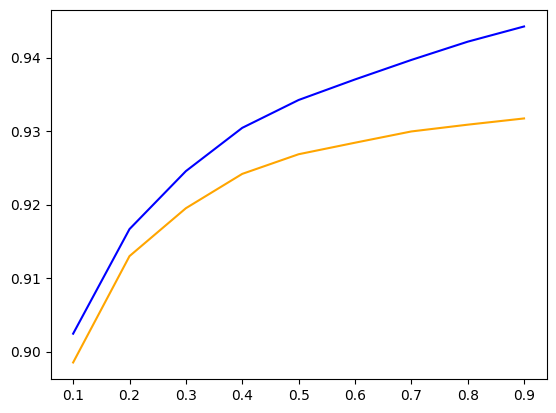

In [230]:
#main focus is AUC for these binary models (i.e. ranking of obs rather than classification of them)
# so, tune the C parameter based on how train and valid AUC differ
bully_type = 'other_cyberbullying'
t_auc = []
v_auc = []
l1_strengths = [x/10 for x in range(1,10)]
for l1 in l1_strengths:
    log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=l1)
    log_reg.fit(train_tfidf, train_targets_dict[bully_type])
    t_auc += [roc_auc_score(train_targets_dict[bully_type],log_reg.predict_proba(train_tfidf)[:,1])]
    v_auc += [roc_auc_score(valid_targets_dict[bully_type],log_reg.predict_proba(valid_tfidf)[:,1])]
    
#plot
sns.lineplot(x=l1_strengths,y=t_auc,color='blue')
sns.lineplot(x=l1_strengths,y=v_auc,color='orange')

#I'm eyeballing that 0.4 looks like a good compromise for the C parameter for the l1 reg


### Final Decision

In [231]:
#use C=0.4 for the L1 reg
# 179 feats, Training AUC: 0.9304 & Valid AUC: 0.9242, and recall up from 0.1 to 0.34
# I am happy with this for now, so add to our model_dict

bully_type = 'other_cyberbullying'
model_dict[bully_type]['model'] = LogisticRegression(penalty='l1', solver='liblinear', C=0.4)
#and fit it
model_dict[bully_type]['model'].fit(train_tfidf, train_targets_dict[bully_type])
#print summary and store features info
model_dict[bully_type]['featimp'], model_dict[bully_type]['featdict'] = tfidf_logreg_summary(model_dict[bully_type]['model'],
                                                                                                train_tfidf,
                                                                                                train_targets_dict[bully_type],
                                                                                                    valid_tfidf,
                                                                                                    valid_targets_dict[bully_type])


=== Model Performance Results ===
Training Accuracy: 0.8730
Valid Accuracy: 0.8694
Training AUC: 0.9304
Valid AUC: 0.9242

Dataset sizes:
Training set: 33384 samples
Valid set: 9538 samples

=== Valid Set Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.93      7973
           1       0.72      0.34      0.46      1565

    accuracy                           0.87      9538
   macro avg       0.80      0.66      0.69      9538
weighted avg       0.85      0.87      0.85      9538


=== Valid Set Confusion Matrix ===
[[7763  210]
 [1036  529]]

=== Feature Importance (Top 40) ===
             feature  coefficient  abs_coefficient
120           muslim   -36.172715        36.172715
149           school   -33.030285        33.030285
123           nigger   -24.763102        24.763102
31         christian   -19.844581        19.844581
70               gay   -17.287315        17.287315
22             black   -14.701844   

# 3 Multi-Classification

## 3.1 Train Data Predictions

In [232]:
#combine the binary models into a single decision of which class each obs falls into!
# I need to get the linear part of the logistic regressions out, and sum them all +1 on the bottom


In [274]:
'''
log(p/1-p) gets us the value of the linear part of logistic regression from the predicted prob p
we actually want exp(linear_part) for our calculations, so we want exp(log(p/1-p))=p/1-p
so for an observation, calculate the probability p_k for each class k of K classes.
then, get exponentiated linear parts by calculating p_k/1-p_k. Call these e_k
then, for our multi-class model, our predicted prob that this observation is in class k is:
e_k/(1+e_1+e_2+...+e_K) 
...or if k is 'non bullying' then we take 1/(1+e_1+e_2+...+e_K)

that way, the propensity scores for each class all add up to 1
'''


"\nlog(p/1-p) gets us the value of the linear part of logistic regression from the predicted prob p\nwe actually want exp(linear_part) for our calculations, so we want exp(log(p/1-p))=p/1-p\nso for an observation, calculate the probability p_k for each class k of K classes.\nthen, get exponentiated linear parts by calculating p_k/1-p_k. Call these e_k\nthen, for our multi-class model, our predicted prob that this observation is in class k is:\ne_k/(1+e_1+e_2+...+e_K) \n...or if k is 'non bullying' then we take 1/(1+e_1+e_2+...+e_K)\n\nthat way, the propensity scores for each class all add up to 1\n"

In [275]:
# fix the indices of each class so we always regard them in the same order with same numeric labels
class_idx_lookup = {'religion':0,
                    'gender':1,
                    'age':2,
                    'ethnicity':3,
                    'other_cyberbullying':4,
                    'not_cyberbullying':5}

In [304]:
# apply this class_idx_lookup to train test and valid dataframes 
for df in [train_df,valid_df,test_df]:
    df['cyberbullying_idx'] = df['cyberbullying_type'].apply(lambda x: class_idx_lookup[x])

train_df.head(5)


,tweet_text,cyberbullying_type,tokens_v1,tweet_v1,cyberbullying_idx
0,FUCK THEM DUMB NIGGERS,ethnicity,"[fuck, dumb, nigger]",fuck dumb nigger,3
1,“@Pretty_BSJ: Bitch stfu .RT @tayyoung_: FUCK ...,ethnicity,"[“@, pretty_bsj, :, bitch, stfu, ., rt, @, tay...",“@ pretty_bsj : bitch stfu . rt @ tayyoung_ : ...,3
2,I refuse to step foot in Hip Hop Chicken. Them...,ethnicity,"[refuse, step, foot, hip, hop, chicken, ., fuc...",refuse step foot hip hop chicken . fuck as egy...,3
3,"Dou um empurrão em uma pessoa, isso se chama :...",not_cyberbullying,"[dou, empurrão, em, uma, pessoa, ,, isso, cham...","dou empurrão em uma pessoa , isso chama : - › ...",5
4,This is just gross. Signed a #Christian woman ...,religion,"[gross, ., signed, #, christian, woman, jesus,...",gross . signed # christian woman jesus teach l...,0


In [276]:
e_list_train = []
for bully_type in class_idx_lookup.keys():
    if bully_type != 'not_cyberbullying':
        p_k = model_dict[bully_type]['model'].predict_proba(train_tfidf)[:,1]
        e_list_train += [p_k/(1-p_k)]

e_list_train



[array([0.00056003, 0.01589495, 0.02051864, ..., 0.02118055, 0.05045633,
        0.00706975], shape=(33384,)),
 array([2.31530715e-05, 1.97056851e-01, 1.43647751e-02, ...,
        6.73481305e-02, 7.16283564e-02, 6.14116107e-03], shape=(33384,)),
 array([3.21125872e-03, 1.07720204e-02, 1.06822274e-02, ...,
        1.44240170e-02, 1.44240170e-02, 2.69889279e+03], shape=(33384,)),
 array([1.36509946e+11, 9.39965979e+00, 1.10508527e+01, ...,
        2.26777018e-01, 3.32544109e-02, 4.59089529e-03], shape=(33384,)),
 array([3.20273998e-09, 8.32194624e-03, 1.79001075e-02, ...,
        7.32817594e-01, 5.40029271e-01, 4.48580559e-03], shape=(33384,))]

In [277]:
e_array_train = np.array(e_list_train)

In [278]:
# suppose I want the scores for class 0 i.e. 'religion'
# e_0/(1+e_0+e_1+...+e_K) 

e_list_train[0]/(1+np.sum(e_array_train,axis=0))


array([4.10251715e-15, 1.49505187e-03, 1.69375119e-03, ...,
       1.02691200e-02, 2.95102106e-02, 2.61850830e-06], shape=(33384,))

In [279]:
class_idx_lookup.values()

dict_values([0, 1, 2, 3, 4, 5])

In [280]:
# so the predicted class for each case will be the index of class_scores that has highest score
class_scores_train = [e_list_train[idx]/(1+np.sum(e_array_train,axis=0)) 
                for bully_type,idx in class_idx_lookup.items() if bully_type!='not_cyberbullying'
                ] + [1/(1+np.sum(e_array_train,axis=0))]



In [281]:
class_scores_train

[array([4.10251715e-15, 1.49505187e-03, 1.69375119e-03, ...,
        1.02691200e-02, 2.95102106e-02, 2.61850830e-06], shape=(33384,)),
 array([1.69607213e-16, 1.85348296e-02, 1.18576832e-03, ...,
        3.26528901e-02, 4.18930140e-02, 2.27457564e-06], shape=(33384,)),
 array([2.35239909e-14, 1.01319777e-03, 8.81785252e-04, ...,
        6.99330238e-03, 8.43612188e-03, 9.99621363e-01], shape=(33384,)),
 array([1.00000000e+00, 8.84115887e-01, 9.12214149e-01, ...,
        1.09949972e-01, 1.94493853e-02, 1.70038507e-06], shape=(33384,)),
 array([2.34615871e-20, 7.82747998e-04, 1.47759922e-03, ...,
        3.55297351e-01, 3.15844938e-01, 1.66146174e-06], shape=(33384,)),
 array([7.32547356e-12, 9.40582858e-02, 8.25469466e-02, ...,
        4.84837365e-01, 5.84866330e-01, 3.70382020e-04], shape=(33384,))]

In [285]:
#for each observation, zip the scores together so we can take argmax to find the largest index
zip_class_scores_train = list(zip(class_scores_train[0],class_scores_train[1],class_scores_train[2],class_scores_train[3],class_scores_train[4],class_scores_train[5]))
zip_class_scores_train


[(np.float64(4.102517150349316e-15),
  np.float64(1.6960721324727343e-16),
  np.float64(2.3523990862518197e-14),
  np.float64(0.9999999999926467),
  np.float64(2.3461587066222896e-20),
  np.float64(7.325473561081504e-12)),
 (np.float64(0.0014950518704479406),
  np.float64(0.018534829617618546),
  np.float64(0.0010131977734824712),
  np.float64(0.8841158869633832),
  np.float64(0.000782747997723393),
  np.float64(0.09405828577734454)),
 (np.float64(0.0016937511891107727),
  np.float64(0.001185768319304088),
  np.float64(0.0008817852516876504),
  np.float64(0.9122141494198788),
  np.float64(0.001477599217347194),
  np.float64(0.08254694660267152)),
 (np.float64(0.03720199794707349),
  np.float64(0.05281235845454629),
  np.float64(0.01063498303525316),
  np.float64(0.024518835231426242),
  np.float64(0.13752105795768219),
  np.float64(0.7373107673740186)),
 (np.float64(0.725956698136856),
  np.float64(0.01406915777177656),
  np.float64(0.0034896024192457398),
  np.float64(0.00800166217458

In [286]:
len(zip_class_scores_train)


33384

In [306]:
predclassidx_train = [int(np.argmax(scores_list)) for scores_list in zip_class_scores_train]
predclassidx_train[0:10]
#final predicted class idxs

[3, 3, 3, 5, 0, 2, 2, 3, 2, 2]

In [308]:
#final pred classes with english names
predclass_train = [list(class_idx_lookup.keys())[idx] for idx in predclassidx_train]

In [303]:
#ALSO final predicted scores
predproba_train = [float(max(scores_list)) for scores_list in zip_class_scores_train]
predproba_train[0:10]
#final predicted probabilities


[0.9999999999926467,
 0.8841158869633832,
 0.9122141494198788,
 0.7373107673740186,
 0.725956698136856,
 0.9638546899640614,
 0.9170911075389709,
 0.9972139082740329,
 0.9983719076896235,
 0.9951639100691168]

## 3.2 Evaluate Train Predictions

In [309]:
#sense check first few cases
for idx in range(5):
    print('tweet:',train_df.loc[train_df.index==idx, 'tweet_text'].min())
    print('true label:',train_df.loc[train_df.index==idx, 'cyberbullying_type'].min())
    print('predicted label:',predclass_train[idx])
    print()

#looks good!!

tweet: FUCK THEM DUMB NIGGERS
true label: ethnicity
predicted label: ethnicity

tweet: “@Pretty_BSJ: Bitch stfu .RT @tayyoung_: FUCK OBAMA, dumb ass nigger”bitches out here trying to get 187'd sis @Pretty_BSJ
true label: ethnicity
predicted label: ethnicity

tweet: I refuse to step foot in Hip Hop Chicken. Them fuck ass egyptians profiting off you dumb niggers. I will not drink the koolaid.
true label: ethnicity
predicted label: ethnicity

tweet: Dou um empurrão em uma pessoa, isso se chama : - › EU : Empurrão. › › SOCIEDADE : Bullying ! http://t.co/09hVKp5
true label: not_cyberbullying
predicted label: not_cyberbullying

tweet: This is just gross. Signed a #Christian woman who knows Jesus was sent to teach us to love more and judge less, to help our neighbor not just the people we think “deserve” it. The New Testament was literally all about love and compassion. You are right you are no bible scholar.
true label: religion
predicted label: religion



Accuracy: 0.7530
                     precision    recall  f1-score   support

                age       0.94      0.89      0.91      5594
          ethnicity       0.98      0.85      0.91      5573
             gender       0.95      0.72      0.82      5581
  not_cyberbullying       0.40      0.84      0.54      5561
other_cyberbullying       0.75      0.33      0.46      5476
           religion       0.97      0.88      0.92      5599

           accuracy                           0.75     33384
          macro avg       0.84      0.75      0.76     33384
       weighted avg       0.84      0.75      0.76     33384

Log Loss: 0.5907


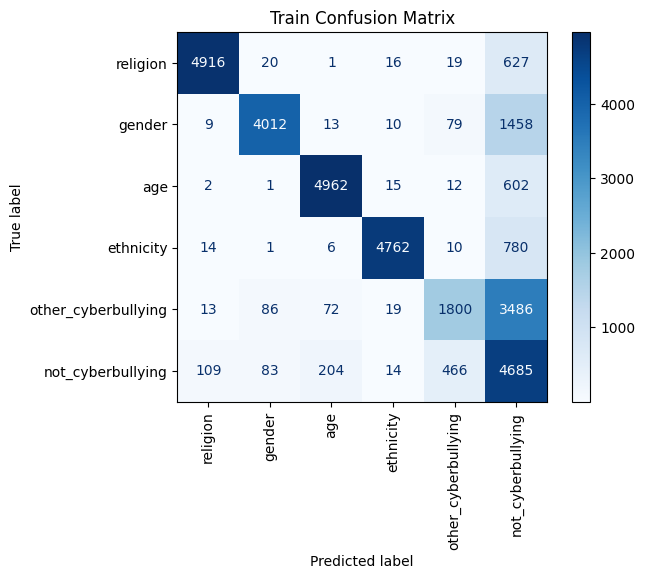

In [316]:
# now try visualising effectiveness of predictions on train data

# Overall accuracy
print(f"Accuracy: {accuracy_score(train_df['cyberbullying_type'], predclass_train):.4f}")

# Per-class precision, recall, F1 + macro/weighted averages
print(classification_report(train_df['cyberbullying_type'], predclass_train))

# Log loss (uses probabilities - penalises confident wrong predictions)
print(f"Log Loss: {log_loss(train_df['cyberbullying_idx'], zip_class_scores_train):.4f}")

# Confusion matrix
cm = confusion_matrix(train_df['cyberbullying_type'], predclass_train,labels=list(class_idx_lookup.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=list(class_idx_lookup.keys()))
disp.plot(cmap='Blues')
plt.title("Train Confusion Matrix")
plt.xticks(rotation=90)
plt.show()

## 3.3 Evaluation Reports

In [ ]:
# for validation and held out test data, write 1 function that makes predictions and evaluates performance

In [333]:
def evaluation_report(df,tfidf_df,dataset_nickname):
    # exponentiated linear-parts of each logistic regression we fitted (all labels except 'not' cyber)
    e_list = []
    for bully_type in class_idx_lookup.keys():
        if bully_type != 'not_cyberbullying':
            p_k = model_dict[bully_type]['model'].predict_proba(tfidf_df)[:,1]
            e_list += [p_k/(1-p_k)]
    
    e_array = np.array(e_list)

    # so the predicted class for each case will be the index of class_scores that has highest score
    class_scores = [e_list[idx]/(1+np.sum(e_array,axis=0)) 
                    for bully_type,idx in class_idx_lookup.items() if bully_type!='not_cyberbullying'
                    ] + [1/(1+np.sum(e_array,axis=0))]
    
    #for each observation, zip the scores together so we can take argmax to find the largest index
    zip_class_scores = list(zip(class_scores[0],class_scores[1],class_scores[2],class_scores[3],class_scores[4],class_scores[5]))

    predclassidx = [int(np.argmax(scores_list)) for scores_list in zip_class_scores]
    #final pred classes with english names
    predclass = [list(class_idx_lookup.keys())[idx] for idx in predclassidx]
    #ALSO final predicted scores
    predproba = [float(max(scores_list)) for scores_list in zip_class_scores]

    # now try visualising effectiveness of predictions on data
    print('=======================')
    print(f"{dataset_nickname} Performance")
    print('=======================')
    print()

    # Overall accuracy
    print(f"Accuracy: {accuracy_score(df['cyberbullying_type'], predclass):.4f}")

    # Per-class precision, recall, F1 + macro/weighted averages
    print(classification_report(df['cyberbullying_type'], predclass))

    # Log loss (uses probabilities - penalises confident wrong predictions)
    print(f"Log Loss: {log_loss(df['cyberbullying_idx'], zip_class_scores):.4f}")

    # Confusion matrix
    cm = confusion_matrix(df['cyberbullying_type'], predclass,labels=list(class_idx_lookup.keys()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=list(class_idx_lookup.keys()))
    disp.plot(cmap='Blues')
    plt.title(f"{dataset_nickname} Confusion Matrix")
    plt.xticks(rotation=90)
    plt.show()





### Validation

Validation Performance

Accuracy: 0.7552
                     precision    recall  f1-score   support

                age       0.92      0.92      0.92      1598
          ethnicity       0.97      0.85      0.91      1592
             gender       0.94      0.75      0.83      1595
  not_cyberbullying       0.41      0.81      0.55      1589
other_cyberbullying       0.71      0.31      0.43      1565
           religion       0.97      0.88      0.92      1599

           accuracy                           0.76      9538
          macro avg       0.82      0.75      0.76      9538
       weighted avg       0.82      0.76      0.76      9538

Log Loss: 0.5992


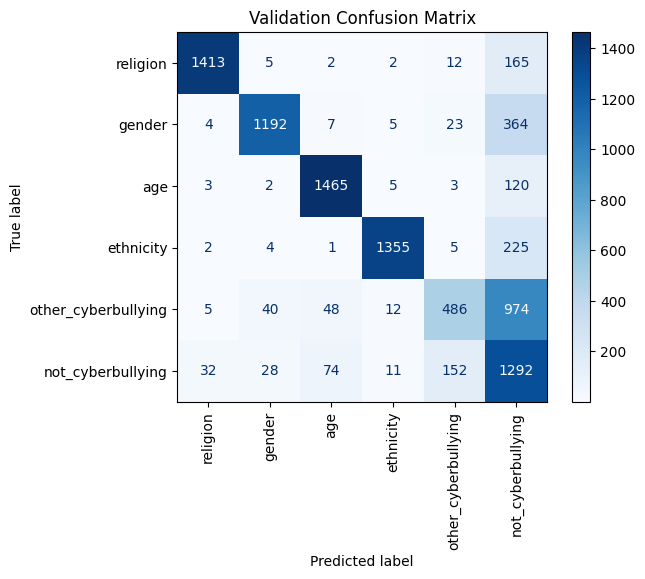

In [334]:
evaluation_report(valid_df,valid_tfidf,'Validation')

### Test

Test Performance

Accuracy: 0.7447
                     precision    recall  f1-score   support

                age       0.90      0.89      0.90       800
          ethnicity       0.99      0.85      0.92       796
             gender       0.93      0.76      0.84       797
  not_cyberbullying       0.39      0.77      0.52       795
other_cyberbullying       0.66      0.28      0.40       782
           religion       0.97      0.89      0.93       800

           accuracy                           0.74      4770
          macro avg       0.81      0.74      0.75      4770
       weighted avg       0.81      0.74      0.75      4770

Log Loss: 0.5965


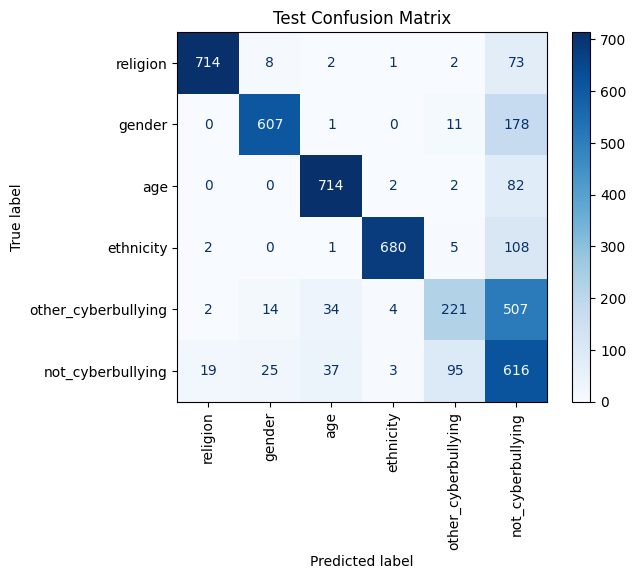

In [335]:
evaluation_report(test_df,test_tfidf,'Test')

# 4 Conclusion

We have managed to very quickly arrive at a 6-class classifier that can take unseen tweets and provide a reliable prediction of how likely the tweet is to contain bullying of 4 specific types (religion, gender, age, ethnicity), or some 'other' type of bullying not specified, or no bullying at all.

We did this by fitting 5 separate binary models (logistic regresions, using tf-idf to engineer features from the tweets). The 5 models were trained on the entire train dataset, and the binary target for these 5 models were as follows:
1. indicator of whether tweet contains cyberbullying_type='religion'
2. indicator of whether tweet contains cyberbullying_type='gender'
3. indicator of whether tweet contains cyberbullying_type='age'
4. indicator of whether tweet contains cyberbullying_type='ethnicity'
5. indicator of whether tweet contains cyberbullying_type='other_cyberbullying'

The binary models predicting specific bullying types (religion, gender, age, ethnicity) performed extremely well and only required 7-40 features (thanks to L1 regularisation on the logistic regressions). 

The binary model for 'other_cyberbullying' was less predictive, and required inclusion of 179 features to get satisfactory enough performance. The impact of this can be seen in the confusion matrices in section 3.3; several cases that my model predicted to be 'other_cyberbullying' were actually 'not_cyberbullying', and vice versa!

The technique to combine our 5 binary models into a final prediction is based on the predicted probabilities calculated like so:

$$P(Y = k \mid \mathbf{x}) = \frac{e^{\mathbf{x}^\top \boldsymbol{\beta}_k}}{1 + \sum_{j=1}^{K-1} e^{\mathbf{x}^\top \boldsymbol{\beta}_j}}$$

$$P(Y = K \mid \mathbf{x}) = \frac{1}{1 + \sum_{j=1}^{K-1} e^{\mathbf{x}^\top \boldsymbol{\beta}_j}}$$

For our example, K=6 and the class K shown at the bottom is 'not_cyberbullying'.